# Import

In [12]:
import os
import numpy as np
import mne
import xml.etree.ElementTree as ET
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Paths, Labels, and Filter Setup

In [13]:
signals_path = r"C:\Users\Specialist\OneDrive\Desktop\sleep\dataset\Signals"
annotations_path = r"C:\Users\Specialist\OneDrive\Desktop\sleep\dataset\Annotations"

label_map = {
    'Wake|0': 0,
    'Stage 1 sleep|1': 1,
    'Stage 2 sleep|2': 2,
    'Stage 3 sleep|3': 3,
    'REM sleep|5': 4
}
# bandpass filter
def bandpass_filter(signal, fs):
    nyq = 0.5 * fs # Nyquist frequency
    lowcut, highcut = 0.3, 35
    b, a = butter(4, [lowcut/nyq, highcut/nyq], btype='band')  
    return filtfilt(b, a, signal)

print("Settings and Filter Ready")

Settings and Filter Ready


# Load and Pair EDF & XML Files

In [14]:
edf_files = sorted([f for f in os.listdir(signals_path) if f.endswith('.edf')])
xml_files = sorted([f for f in os.listdir(annotations_path) if f.endswith('.xml')])
# بربط كل signal مع الـ annotation بتاعها
file_pairs = list(zip(edf_files, xml_files))
print(f"Found {len(file_pairs)} pairs of files to process.")

Found 10 pairs of files to process.


# Signal Processing and Data Extraction (EOG-L)

In [15]:
all_segments = []
all_labels = []
target_channels = ['EOG-L'] # using left eye channel
window_duration = 30 # each segment = 30 sec

for edf_file, xml_file in file_pairs:
    raw = mne.io.read_raw_edf(os.path.join(signals_path, edf_file), preload=True, include=target_channels, verbose=False)
    fs = raw.info['sfreq']
    
    # 1. filtering
    eog_data = bandpass_filter(raw.get_data(picks=['EOG-L'])[0], fs)  
    
    # 2. z-score normalization 
    eog_data = (eog_data - np.mean(eog_data)) / (np.std(eog_data) + 1e-8)
    
    samples_per_epoch = int(window_duration * fs)  
    segments = []  
    
    # split into 30-sec segments
    for i in range(0, len(eog_data) - samples_per_epoch + 1, samples_per_epoch):  
        segment = eog_data[i:i + samples_per_epoch, np.newaxis] 
        segments.append(segment)  

    # نقرا ال XML
    tree = ET.parse(os.path.join(annotations_path, xml_file))  
    root = tree.getroot()  
    stages = []  

    #نطلع ال labels من ال XML
    for event in root.iter('ScoredEvent'):  
        concept = event.find('EventConcept').text  
        duration = float(event.find('Duration').text)  
        if concept in label_map:  
            num_epochs = int(duration / 30)  
            stages.extend([label_map[concept]] * num_epochs)  

    min_len = min(len(segments), len(stages))  
    all_segments.extend(segments[:min_len])  
    all_labels.extend(stages[:min_len])

X = np.array(all_segments) 
y = np.array(all_labels)
print("Data Extraction Complete. X shape:", X.shape)

Data Extraction Complete. X shape: (12758, 7680, 1)


# Data split

In [16]:
# قسمنا الداتا : train =70% و val=15% و test=15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y # يخلي ال class distribution يكون balanced
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (8930, 7680, 1)
Validation: (1914, 7680, 1)
Test: (1914, 7680, 1)


# Convert Labels to Categorical (One-Hot Encoding)

In [17]:
from tensorflow.keras.utils import to_categorical

#تحويل ال labels ل categorical
y_train_categorical = to_categorical(y_train, num_classes=5)
y_val_categorical = to_categorical(y_val, num_classes=5)
y_test_categorical = to_categorical(y_test, num_classes=5)

# Class Weights

In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights_dict = {
    0: 1.0,   # Wake
    1: 4.0,   # Stage1
    2: 1.5,   # Stage2
    3: 2.0,   # Stage3
    4: 2.5    # REM
}

print(class_weights_dict)

{0: 1.0, 1: 4.0, 2: 1.5, 3: 2.0, 4: 2.5}


# CNN-BiLSTM Model

In [19]:
samples_per_epoch = int(window_duration * fs)
print(f"Input shape: ({samples_per_epoch}, 1)")

model = Sequential([
    Input(shape=(samples_per_epoch, 1)),

    # CNN layers (feature extraction)
    Conv1D(64, kernel_size=50, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(8),

    Conv1D(128, kernel_size=15, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(8),

    Conv1D(128, kernel_size=5, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(4),

    # temporal learning
    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("Model Ready")

Input shape: (7680, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 7680, 64)       │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7680, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 960, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 960, 128)       │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 960, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 120, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 120, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,997 (1.21 MB)

 Trainable params: 316,357 (1.21 MB)

 Non-trainable params: 640 (2.50 KB)

Model Ready


# Model Training

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-6
)
# تدريب الموديل
history = model.fit(
    X_train, y_train_categorical,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val_categorical),
    class_weight=class_weights_dict,
    callbacks=[early_stop, lr_scheduler]
)

print("Training Finished")

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.6345 - loss: 1.8203 - val_accuracy: 0.1808 - val_loss: 1.8494 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6825 - loss: 1.4677 - val_accuracy: 0.2989 - val_loss: 1.6838 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.7200 - loss: 1.2782 - val_accuracy: 0.4441 - val_loss: 1.4581 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7390 - loss: 1.1979 - val_accuracy: 0.5491 - val_loss: 0.8931 - learning_rate: 0.0010
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7492 - loss: 1.1418 - val_accuracy: 0.5695 - val_loss: 1.0302 - learning_rate: 0.0010
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7670 - loss: 1.0956 - val_accuracy: 0.6876 - val_loss: 0.7313 - learning_rate: 0.0010
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.7737 - loss: 1.

# Model Evaluation

60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.7670 - loss: 0.5831
Final Accuracy: 76.70%
60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 261ms/step
              precision    recall  f1-score   support

        Wake       1.00      0.82      0.90       836
     Stage 1       0.31      0.74      0.44       141
     Stage 2       0.81      0.80      0.80       618
     Stage 3       0.85      0.35      0.50       130
         REM       0.60      0.71      0.65       189

    accuracy                           0.77      1914
   macro avg       0.71      0.69      0.66      1914
weighted avg       0.84      0.77      0.78      1914



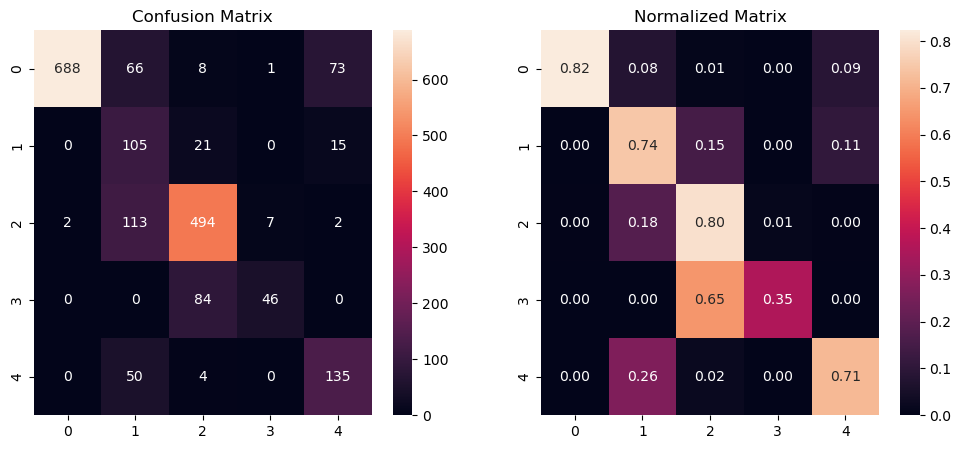

In [21]:
loss, accuracy = model.evaluate(X_test, y_test_categorical)
print(f"Final Accuracy: {accuracy*100:.2f}%")

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test, y_pred,
    target_names=['Wake', 'Stage 1', 'Stage 2', 'Stage 3', 'REM']
))

cm = confusion_matrix(y_test, y_pred)

# normalize
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, fmt='.2f')
plt.title("Normalized Matrix")

plt.show()

# ROC Curve

60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 267ms/step


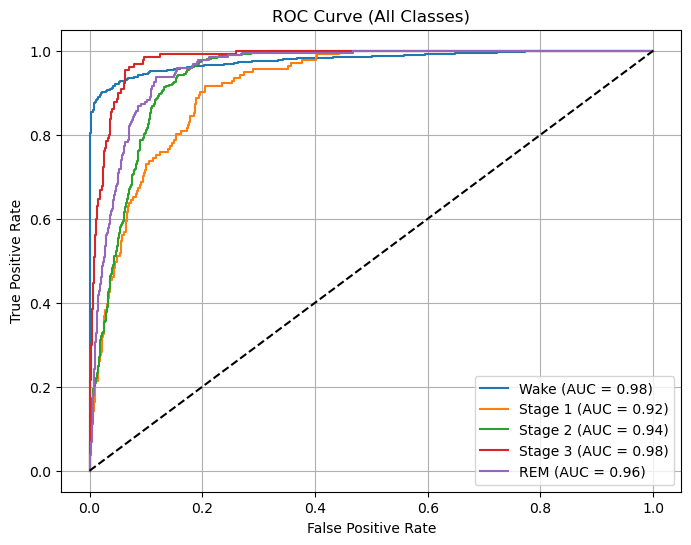

In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# نحول labels لـ one-hot 
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

#prediction probabilities
y_score = model.predict(X_test)

n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

# نحسب ROC لكل class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plot
plt.figure(figsize=(8,6))

class_names = ['Wake', 'Stage 1', 'Stage 2', 'Stage 3', 'REM']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend()
plt.grid()

plt.show()

# Precision, Recall, and F1-score Visualization

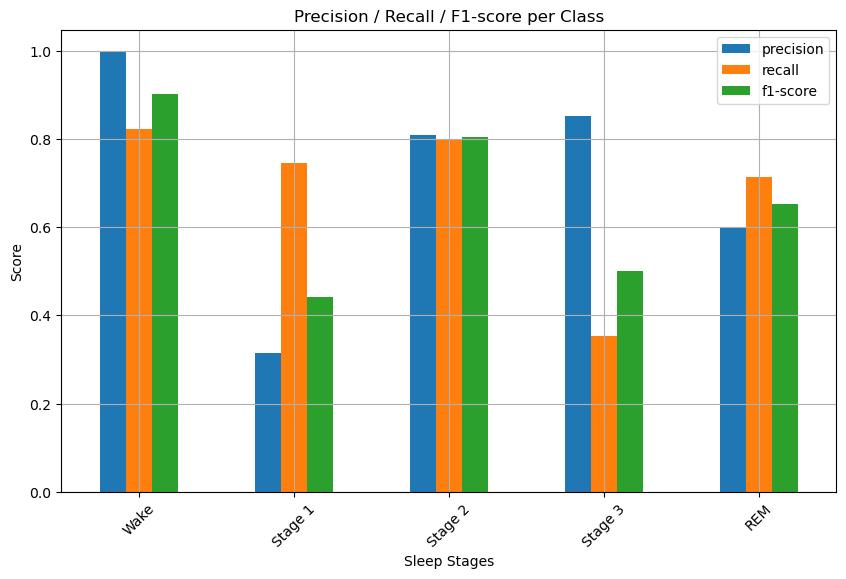

In [23]:
from sklearn.metrics import classification_report
import pandas as pd

# نحول ال report ل dataframe
report = classification_report(
    y_test, y_pred,
    target_names=['Wake', 'Stage 1', 'Stage 2', 'Stage 3', 'REM'],
    output_dict=True
)

df = pd.DataFrame(report).transpose()

# the classes 
df = df.iloc[:5]


# plot precision و recall و f1
df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10,6))

plt.title("Precision / Recall / F1-score per Class")
plt.xlabel("Sleep Stages")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid()

plt.show()

# Model Learning Curves (Accuracy & Loss)

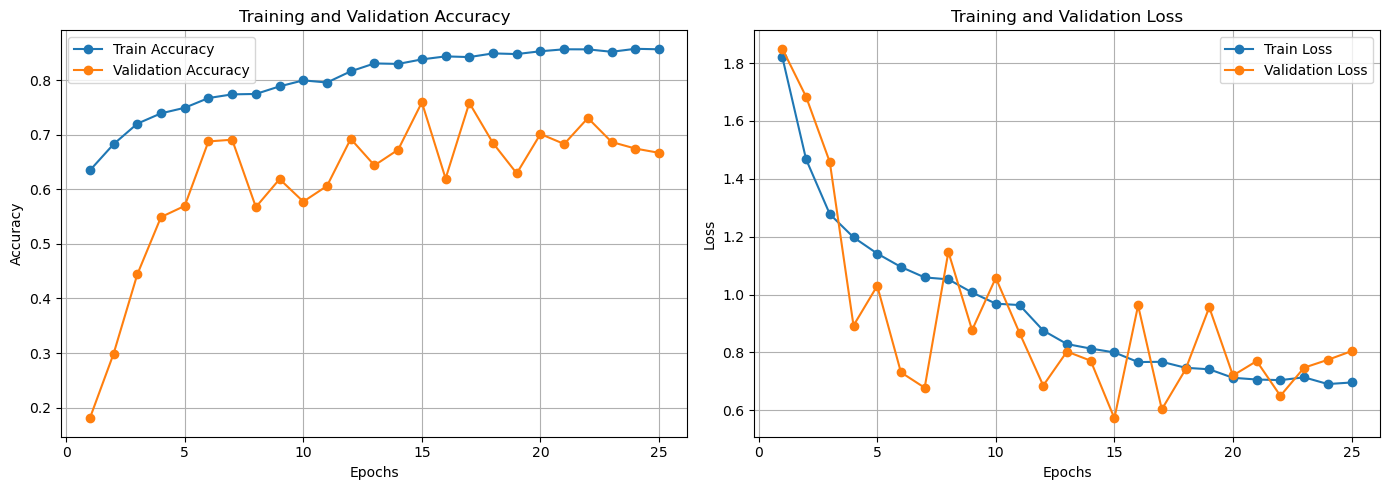

In [24]:
import matplotlib.pyplot as plt

# نجيب القيم من history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(train_acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()